# Lab 3

**Name:** K Hiroshini  
**Roll No:** CH.SC.U4AIE24026

## Part 1: Theoretical Analysis

### 1. Impact of Batch Size
Small batch size (e.g., 16) gives noisier gradients but can help escape local minima and improve generalization. Large batch size (e.g., 256) provides stable gradients and faster convergence per epoch but may converge to sharp minima that generalize poorly. Smaller batches act as implicit regularization.

### 2. Role of Dropout Rate
Dropout randomly sets a fraction of neurons to zero during training, preventing co-adaptation. At 0.0, no regularization and risk of overfitting. At 0.3, moderate regularization with good balance. At 0.5, strong regularization that may cause underfitting if too high. Increasing dropout generally reduces the generalization gap.

## Part 2: Output Analysis & Optimization Log

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

print(f"Training: {len(X_train)}, Validation: {len(X_val)}, Features: {X_train.shape[1]}, Classes: {len(np.unique(y))}")

Training: 120, Validation: 30, Features: 4, Classes: 3


In [2]:
class MLP_Iris(nn.Module):
    def __init__(self, hidden_units=8, dropout_rate=0.0):
        super(MLP_Iris, self).__init__()
        self.fc1 = nn.Linear(4, hidden_units)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_units, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def train_and_evaluate(hidden_units, dropout_rate, batch_size, lr, epochs=50):
    torch.manual_seed(42)
    model = MLP_Iris(hidden_units=hidden_units, dropout_rate=dropout_rate)
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        correct_train = 0
        total_train = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == y_batch).sum().item()
            total_train += len(y_batch)
        train_losses.append(epoch_loss / len(train_loader))
        train_accs.append(correct_train / total_train)

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_preds = torch.argmax(val_outputs, dim=1)
            val_acc = (val_preds == y_val_tensor).float().mean().item()
            val_accs.append(val_acc)

    return train_losses[-1], train_accs[-1], val_accs[-1]

In [3]:
configs = [
    {'hidden_units': 8, 'dropout': 0.0, 'batch_size': 16, 'lr': 0.01},
    {'hidden_units': 8, 'dropout': 0.0, 'batch_size': 16, 'lr': 0.1},
    {'hidden_units': 16, 'dropout': 0.0, 'batch_size': 4, 'lr': 0.01},
    {'hidden_units': 8, 'dropout': 0.3, 'batch_size': 16, 'lr': 0.01},
    {'hidden_units': 4, 'dropout': 0.5, 'batch_size': 4, 'lr': 0.001},
]

results = []
for i, cfg in enumerate(configs):
    final_loss, train_acc, val_acc = train_and_evaluate(
        hidden_units=cfg['hidden_units'],
        dropout_rate=cfg['dropout'],
        batch_size=cfg['batch_size'],
        lr=cfg['lr']
    )
    overfitting = (train_acc - val_acc) > 0.1
    results.append({
        'Trial': i + 1,
        'Hyperparameters': f"H={cfg['hidden_units']}, D={cfg['dropout']}, B={cfg['batch_size']}, LR={cfg['lr']}",
        'Training Loss': round(final_loss, 4),
        'Train Acc': round(train_acc, 4),
        'Val Acc': round(val_acc, 4),
        'Overfitting?': 'Yes' if overfitting else 'No'
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Trial           Hyperparameters  Training Loss  Train Acc  Val Acc Overfitting?
     1 H=8, D=0.0, B=16, LR=0.01         0.0464     0.9833   0.9333           No
     2  H=8, D=0.0, B=16, LR=0.1         0.0344     0.9917   0.9000           No
     3 H=16, D=0.0, B=4, LR=0.01         0.0448     0.9750   0.9667           No
     4 H=8, D=0.3, B=16, LR=0.01         0.1836     0.9083   0.9333           No
     5 H=4, D=0.5, B=4, LR=0.001         0.5214     0.8083   0.8333           No


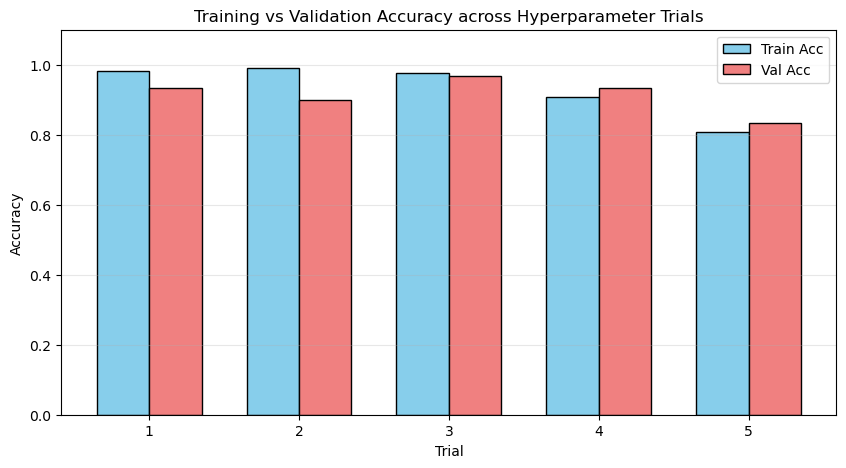

In [4]:
plt.figure(figsize=(10, 5))
trials = [r['Trial'] for r in results]
train_accs = [r['Train Acc'] for r in results]
val_accs = [r['Val Acc'] for r in results]
x = np.arange(len(trials))
width = 0.35
plt.bar(x - width/2, train_accs, width, label='Train Acc', color='skyblue', edgecolor='black')
plt.bar(x + width/2, val_accs, width, label='Val Acc', color='lightcoral', edgecolor='black')
plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy across Hyperparameter Trials')
plt.xticks(x, trials)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.show()